In [80]:
from keras.layers import (Dense, BatchNormalization,
                          Flatten, Conv2D, MaxPooling2D,
                          Input, Activation, Dropout)
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

In [95]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y = np.concatenate((y_train, y_test)).ravel()
x = np.concatenate((x_train, x_test)).astype(np.float32) / 255.0

y = np.where(idx:=np.isin(y, [0,1,8,9]).ravel(), 1, 0)

train_x, test_x, train_y, test_y = train_test_split(x,y,
                                                    test_size=0.2,
                                                    train_size=0.8,
                                                    stratify=y,
                                                    shuffle=True
)

test_y = to_categorical(test_y,2)
train_y = to_categorical(train_y,2)

models = []
class_names = ['automobile','animal']

/Users/artempanchul/miniconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [82]:
def build_model(conv_layers_number: int) -> Sequential:
    md = Sequential([Input(shape=(32, 32, 3))])

    for i in range(5,5+conv_layers_number):
        md.add(Conv2D(2**i, kernel_size=(3, 3), padding='same'))
        md.add(BatchNormalization())
        md.add(Activation('relu'))
        md.add(MaxPooling2D(pool_size=(2, 2)))

    md.add(Flatten())
    md.add(Dense(128, activation='relu'))
    md.add(Dropout(0.2))
    md.add(Dense(len(class_names), activation='softmax'))

    return md

def fit(md: Sequential) -> None:
    es = EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        min_delta=1e-3,
        mode='max',
        restore_best_weights=True
    )

    rlp = ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=2,
        min_delta=1e-3,
        min_lr=1e-4,
        mode='max',
    )

    md.compile(
        loss='categorical_crossentropy',
        metrics=['accuracy'],
        optimizer=Adam(learning_rate=4e-4)
    )

    md.summary()

    md.fit(train_x, train_y,
           epochs=20,
           batch_size=128,
           validation_data=(test_x, test_y),
           callbacks=[es, rlp]
    )

def show_accuracy(md: Sequential) -> None:
    loss, accuracy = md.evaluate(test_x, test_y, verbose=0)
    print('Test accuracy:', f"{accuracy:.2f}")
    print('Test loss:', f"{loss:.2f}")

In [83]:
models.append(model1 := build_model(1))
fit(model1)
show_accuracy(model1)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,049,986 (4.01 MB)

 Trainable params: 1,049,922 (4.01 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8454 - loss: 0.3844 - val_accuracy: 0.8890 - val_loss: 0.3568 - learning_rate: 4.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8969 - loss: 0.2631 - val_accuracy: 0.8708 - val_loss: 0.3019 - learning_rate: 4.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9054 - loss: 0.2382 - val_accuracy: 0.8863 - val_loss: 0.2674 - learning_rate: 4.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9151 - loss: 0.2184 - val_accuracy: 0.9150 - val_loss: 0.2239 - learning_rate: 2.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9169 - loss: 0.2147 - val_accuracy: 0.9007 - val_loss: 0.2400 - learning_rate: 2.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9211 - loss: 0.2062 - val_accuracy: 0.9116 - val_loss: 0.2198 - learning_rate: 2.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/ste

In [84]:
models.append(model2 := build_model(2))
fit(model2)
show_accuracy(model2)

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,450 (2.08 MB)

 Trainable params: 544,258 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.8864 - loss: 0.2779 - val_accuracy: 0.7797 - val_loss: 0.4632 - learning_rate: 4.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9171 - loss: 0.2082 - val_accuracy: 0.9128 - val_loss: 0.2167 - learning_rate: 4.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9295 - loss: 0.1810 - val_accuracy: 0.8478 - val_loss: 0.3654 - learning_rate: 4.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9337 - loss: 0.1667 - val_accuracy: 0.9281 - val_loss: 0.1842 - learning_rate: 4.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9399 - loss: 0.1531 - val_accuracy: 0.9362 - val_loss: 0.1694 - learning_rate: 4.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9450 - loss: 0.1426 - val_accuracy: 0.9378 - val_loss: 0.1628 - learning_rate: 4.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/ste

In [85]:
models.append(model3 := build_model(3))
fit(model3)
show_accuracy(model3)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,674 (1.36 MB)

 Trainable params: 356,226 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 59ms/step - accuracy: 0.8905 - loss: 0.2691 - val_accuracy: 0.6890 - val_loss: 0.8009 - learning_rate: 4.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9235 - loss: 0.1944 - val_accuracy: 0.9063 - val_loss: 0.2297 - learning_rate: 4.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9299 - loss: 0.1743 - val_accuracy: 0.8624 - val_loss: 0.3240 - learning_rate: 4.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9406 - loss: 0.1511 - val_accuracy: 0.9162 - val_loss: 0.2166 - learning_rate: 4.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.9463 - loss: 0.1364 - val_accuracy: 0.9130 - val_loss: 0.2245 - learning_rate: 4.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.9525 - loss: 0.1212 - val_accuracy: 0.9031 - val_loss: 0.2810 - learning_rate: 4.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/ste

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


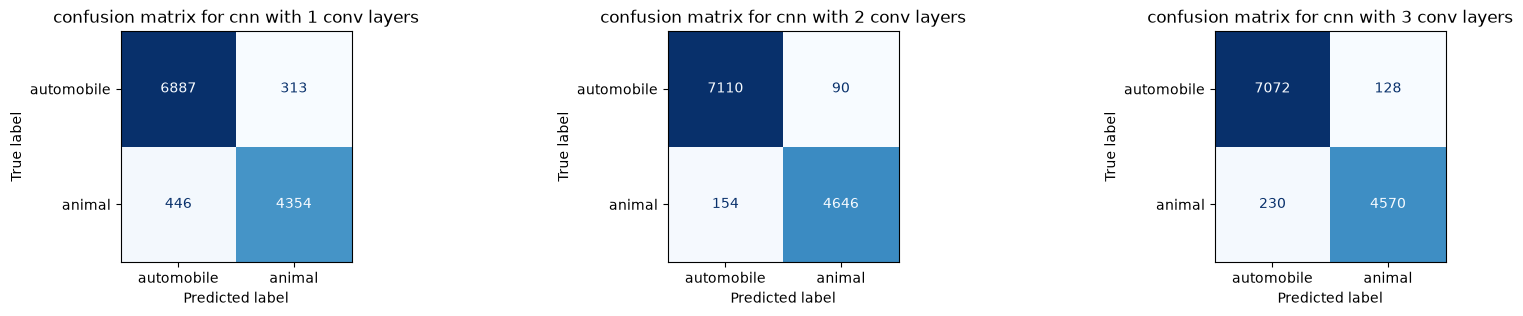

In [98]:
fig, axes = plt.subplots(1,3, figsize=(20,3))
labels = np.argmax(test_y, axis=1)

for i in range(len(models)):
    model = models[i]
    predictions = np.argmax(model.predict(test_x), axis=1)
    cm = confusion_matrix(labels, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'confusion matrix for cnn with {i+1} conv layers')

plt.show()